# Compare models, select, and evaluate\n


This notebook calls the reproducible comparison engine used by `backend/train_model.py`. It creates one stratified 80/20 train/test split and leaves the test set untouched until the final evaluation. On the training portion it compares 4 model families × 3 imbalance strategies using repeated 5-fold stratified CV and average precision (PR-AUC).\n


Preprocessing (median/mode imputation, numeric scaling, and `OneHotEncoder(drop='if_binary')`) and SMOTE are inside each imbalanced-learn pipeline, so each CV fold learns preprocessing and resampling from its training rows only. Paired strategy comparisons use the Nadeau–Bengio corrected t-test with Holm adjustment.\n


The deployed API remains XGBoost so it can use exact TreeSHAP. Its imbalance strategy is selected by repeated-CV PR-AUC among the three XGBoost candidates; the overall CV winner is reported separately. The decision threshold is selected from 5-fold out-of-fold predictions on training data, never from the locked test set.\n


The final XGBoost pipeline is refit on the full training split, evaluated once on the test split, and accompanied by 2,000-resample bootstrap 95% intervals for PR-AUC, ROC-AUC, and F1. SHAP additivity is checked in probability space, with one global beeswarm and local TP/TN/FP/FN/borderline waterfall plots saved under `reports/figures/`.

In [22]:
from pathlib import Path

import sys

import importlib

import pandas as pd

import matplotlib.pyplot as plt

import shap

from IPython.display import Image, display



PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == 'notebooks':

    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'backend'))



import model_comparison

import train_model

importlib.reload(model_comparison)

importlib.reload(train_model)

from train_model import train_and_evaluate, load_and_clean_data, FEATURES

from app.ml.explainer import ChurnExplainer



print(f'Project root: {PROJECT_ROOT}')

print(f'Training entrypoint: {train_and_evaluate.__module__}.{train_and_evaluate.__name__}')

print(f'SHAP version: {shap.__version__}')

print('MLflow tracking URI:', model_comparison._resolve_mlflow_tracking_uri())

Project root: d:\churnxai
Training entrypoint: train_model.train_and_evaluate
SHAP version: 0.44.0
MLflow tracking URI: http://127.0.0.1:5000


In [14]:
results = train_and_evaluate(

    data_path=PROJECT_ROOT / 'data' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv',

    model_dir=PROJECT_ROOT / 'backend' / 'models',

    processed_path=PROJECT_ROOT / 'data' / 'processed' / 'telco_clean.csv',

    figures_dir=PROJECT_ROOT / 'reports' / 'figures',

    metrics_path=PROJECT_ROOT / 'reports' / 'metrics' / 'model_evaluation.json',

    random_state=42,

    n_bootstrap=2000,

    cv_splits=5,

    cv_repeats=2,

    mlp_epochs=35,

)

metadata = results['metadata']

print(f"Overall CV winner: {metadata['model_comparison']['overall_cv_champion']}")

print(f"Deployed XGBoost strategy: {metadata['imbalance_strategy']}")

print(f"OOF-selected threshold: {metadata['decision_threshold']:.3f}")

Logging MLflow runs to http://127.0.0.1:5000


2026/10/05 02:15:57 INFO mlflow.tracking.fluent: Experiment with name 'telco-churn-model-comparison' does not exist. Creating a new experiment.


🏃 View run logistic-regression-none at: http://127.0.0.1:5000/#/experiments/364763333512809843/runs/8294e7347b9c4d9691c6a91a2d397539
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/364763333512809843
🏃 View run logistic-regression-class_weight at: http://127.0.0.1:5000/#/experiments/364763333512809843/runs/a492e2447ac44588953df6717a8af9a2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/364763333512809843


Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  File "c:\Users\amkmu\miniconda3\envs\churnxai\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\amkmu\miniconda3\envs\churnxai\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amkmu\miniconda3\envs\churnxai\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\amkmu\miniconda3\envs\churnxai\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^

🏃 View run logistic-regression-smote at: http://127.0.0.1:5000/#/experiments/364763333512809843/runs/91dadcaea1b0494fb1cfcc97154a0ef9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/364763333512809843
🏃 View run random-forest-none at: http://127.0.0.1:5000/#/experiments/364763333512809843/runs/7a0131531bcb4685987340eac88b683a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/364763333512809843
🏃 View run random-forest-class_weight at: http://127.0.0.1:5000/#/experiments/364763333512809843/runs/c5c7e516227c4a39ac46cb3b80e06f26
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/364763333512809843
🏃 View run random-forest-smote at: http://127.0.0.1:5000/#/experiments/364763333512809843/runs/5195760a45bd43d7be591a65e611c337
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/364763333512809843
🏃 View run xgboost-none at: http://127.0.0.1:5000/#/experiments/364763333512809843/runs/7e963d1f37314cdfb19d0655aaa28d28
🧪 View experiment at: http://127.0.0.1:5000/#/e

[02:20:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


🏃 View run repeated-cv-comparison-seed-42 at: http://127.0.0.1:5000/#/experiments/364763333512809843/runs/87f4790f4503416ca6df265132a4fef5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/364763333512809843
Overall CV winner: {'model': 'XGBoost', 'imbalance_strategy': 'none', 'cv_pr_auc_mean': 0.67142974694622, 'cv_pr_auc_std': 0.019404978041666708}
Deployed XGBoost strategy: none
OOF-selected threshold: 0.335


In [19]:
metric_names = [

    'average_precision', 'roc_auc', 'accuracy', 'balanced_accuracy',

    'precision', 'recall', 'f1', 'brier_score',

]

ci_keys = {'average_precision': 'pr_auc', 'roc_auc': 'roc_auc', 'f1': 'f1'}

test_metrics = metadata['test_metrics']

intervals = metadata['test_metrics_95ci']

metrics_table = pd.DataFrame({

    'test_value': {name: test_metrics[name] for name in metric_names},

    '95% bootstrap CI': {

        name: (

            f"[{intervals[ci_keys[name]]['ci_low']:.3f}, {intervals[ci_keys[name]]['ci_high']:.3f}]"

            if name in ci_keys and ci_keys[name] in intervals

            else 'Not calculated'

        )

        for name in metric_names

    },

})

display(metrics_table)

display(pd.read_csv(results['comparison_path']).drop(columns=['cv_fold_scores']))

display(pd.DataFrame(metadata['model_comparison']['nadeau_bengio_strategy_tests']))

print('Overall CV champion:', metadata['model_comparison']['overall_cv_champion'])

print('XGBoost deployment configuration:', metadata['model_comparison']['deployment_xgboost_config'])

display(metadata['split_rows'])

display(test_metrics['confusion_matrix'])

,test_value,95% bootstrap CI
average_precision,0.664748,"[0.611, 0.713]"
roc_auc,0.847444,"[0.825, 0.868]"
accuracy,0.774308,Not calculated
balanced_accuracy,0.759289,Not calculated
precision,0.557377,Not calculated
recall,0.727273,Not calculated
f1,0.631090,"[0.589, 0.667]"
brier_score,0.134583,Not calculated


,model,imbalance_strategy,cv_pr_auc_mean,cv_pr_auc_std
0,XGBoost,none,0.671430,0.019405
1,XGBoost,class_weight,0.670262,0.020896
2,XGBoost,smote,0.663024,0.020049
3,Logistic Regression,none,0.661248,0.018364
4,Logistic Regression,class_weight,0.659926,0.017747
5,Logistic Regression,smote,0.658924,0.020865
6,PyTorch MLP,none,0.658398,0.021343
7,PyTorch MLP,class_weight,0.657834,0.020702
8,Random Forest,none,0.643359,0.027742
9,PyTorch MLP,smote,0.642365,0.024836


,model,first_strategy,second_strategy,mean_pr_auc_difference,corrected_t_statistic,degrees_freedom,p_value,p_holm,significant_holm
0,Logistic Regression,none,class_weight,0.001323,1.058914,9,0.317230,1.000000,False
1,Logistic Regression,none,smote,0.002324,1.154646,9,0.277972,1.000000,False
2,Logistic Regression,class_weight,smote,0.001001,0.378952,9,0.713509,1.000000,False
3,Random Forest,none,class_weight,0.001853,0.803060,9,0.442631,1.000000,False
4,Random Forest,none,smote,0.019128,7.296633,9,0.000046,0.000550,True
5,Random Forest,class_weight,smote,0.017275,4.549378,9,0.001387,0.015259,True
6,XGBoost,none,class_weight,0.001168,0.855467,9,0.414486,1.000000,False
7,XGBoost,none,smote,0.008405,1.718548,9,0.119818,0.958543,False
8,XGBoost,class_weight,smote,0.007238,1.444933,9,0.182377,1.000000,False
9,PyTorch MLP,none,class_weight,0.000563,0.229688,9,0.823469,1.000000,False


Overall CV champion: {'model': 'XGBoost', 'imbalance_strategy': 'none', 'cv_pr_auc_mean': 0.67142974694622, 'cv_pr_auc_std': 0.019404978041666708}
XGBoost deployment configuration: {'model': 'XGBoost', 'imbalance_strategy': 'none', 'cv_pr_auc_mean': 0.67142974694622, 'cv_pr_auc_std': 0.019404978041666708}


{'train': 5634, 'test': 1409}

{'true_negative': 819,
 'false_positive': 216,
 'false_negative': 102,
 'true_positive': 272}

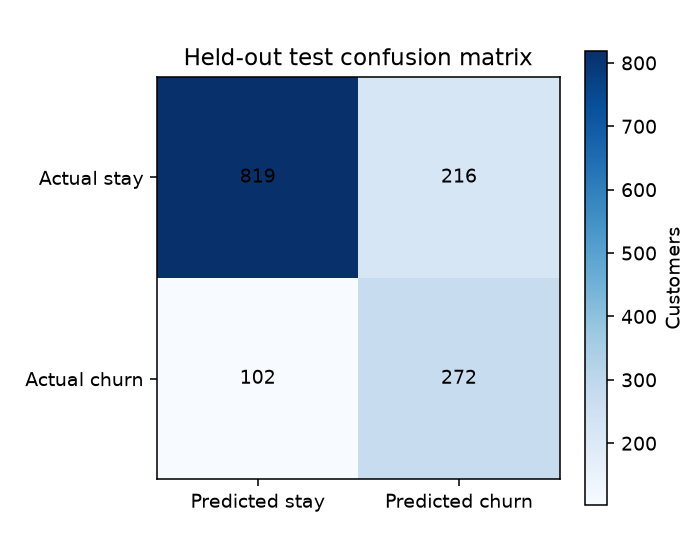

In [16]:
confusion = test_metrics['confusion_matrix']

matrix = [[confusion['true_negative'], confusion['false_positive']],

          [confusion['false_negative'], confusion['true_positive']]]

fig, ax = plt.subplots(figsize=(5, 4))

image = ax.imshow(matrix, cmap='Blues')

ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['Predicted stay', 'Predicted churn'],

       yticklabels=['Actual stay', 'Actual churn'], title='Held-out test confusion matrix')

for row in range(2):

    for column in range(2):

        ax.text(column, row, matrix[row][column], ha='center', va='center', color='black')

fig.colorbar(image, ax=ax, label='Customers')

fig.tight_layout()

confusion_path = PROJECT_ROOT / 'reports' / 'figures' / 'test_confusion_matrix.png'

confusion_path.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(confusion_path, dpi=140)

plt.close(fig)

display(Image(filename=str(confusion_path)))

Maximum SHAP additivity probability error: 2.98e-07
Global explanation: d:\churnxai\reports\figures\shap_global_beeswarm.png


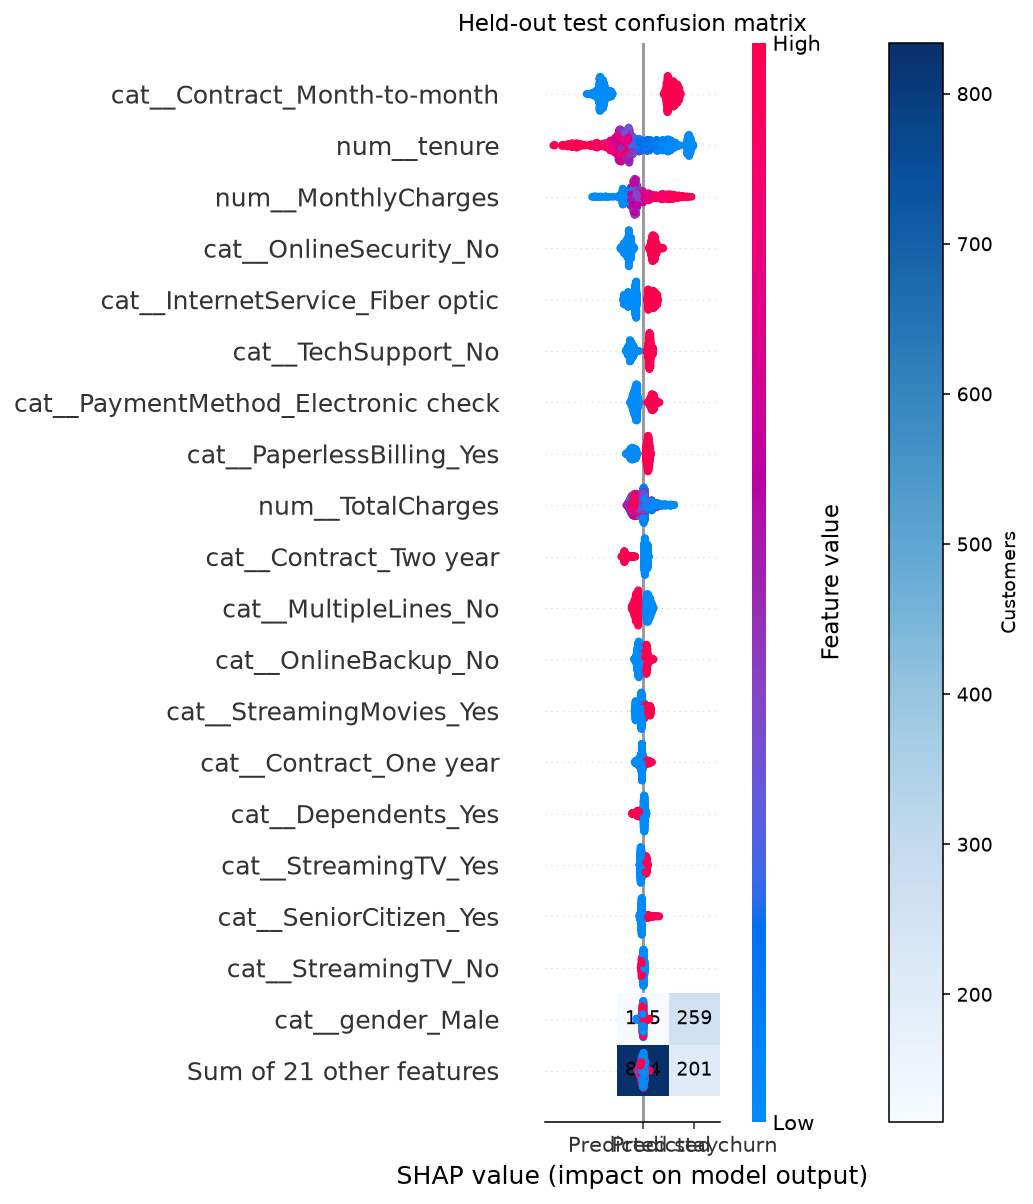

TP local explanation: d:\churnxai\reports\figures\shap_local_tp.png


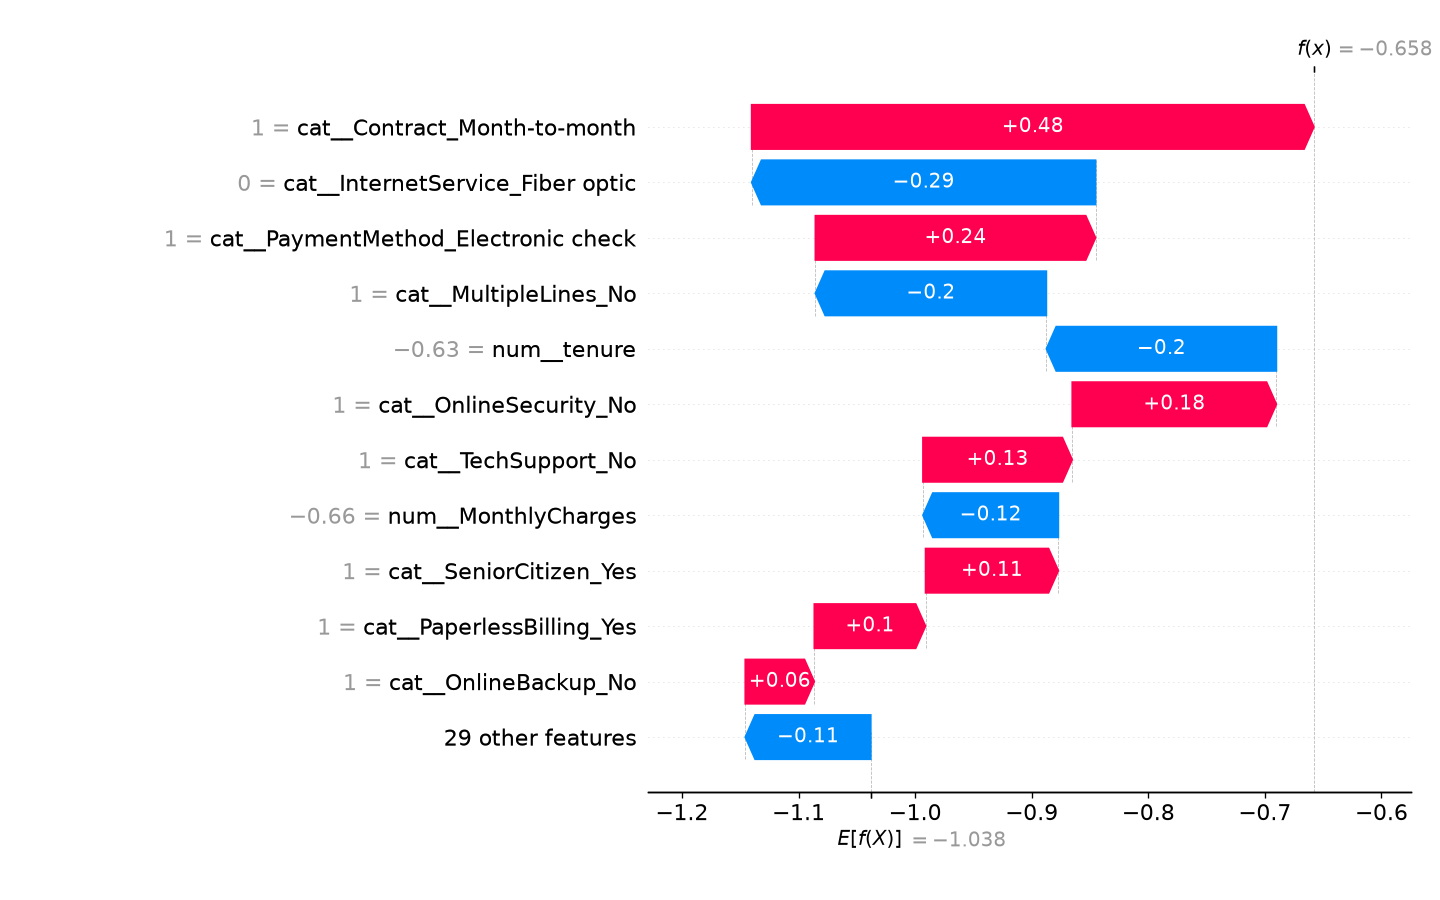

TN local explanation: d:\churnxai\reports\figures\shap_local_tn.png


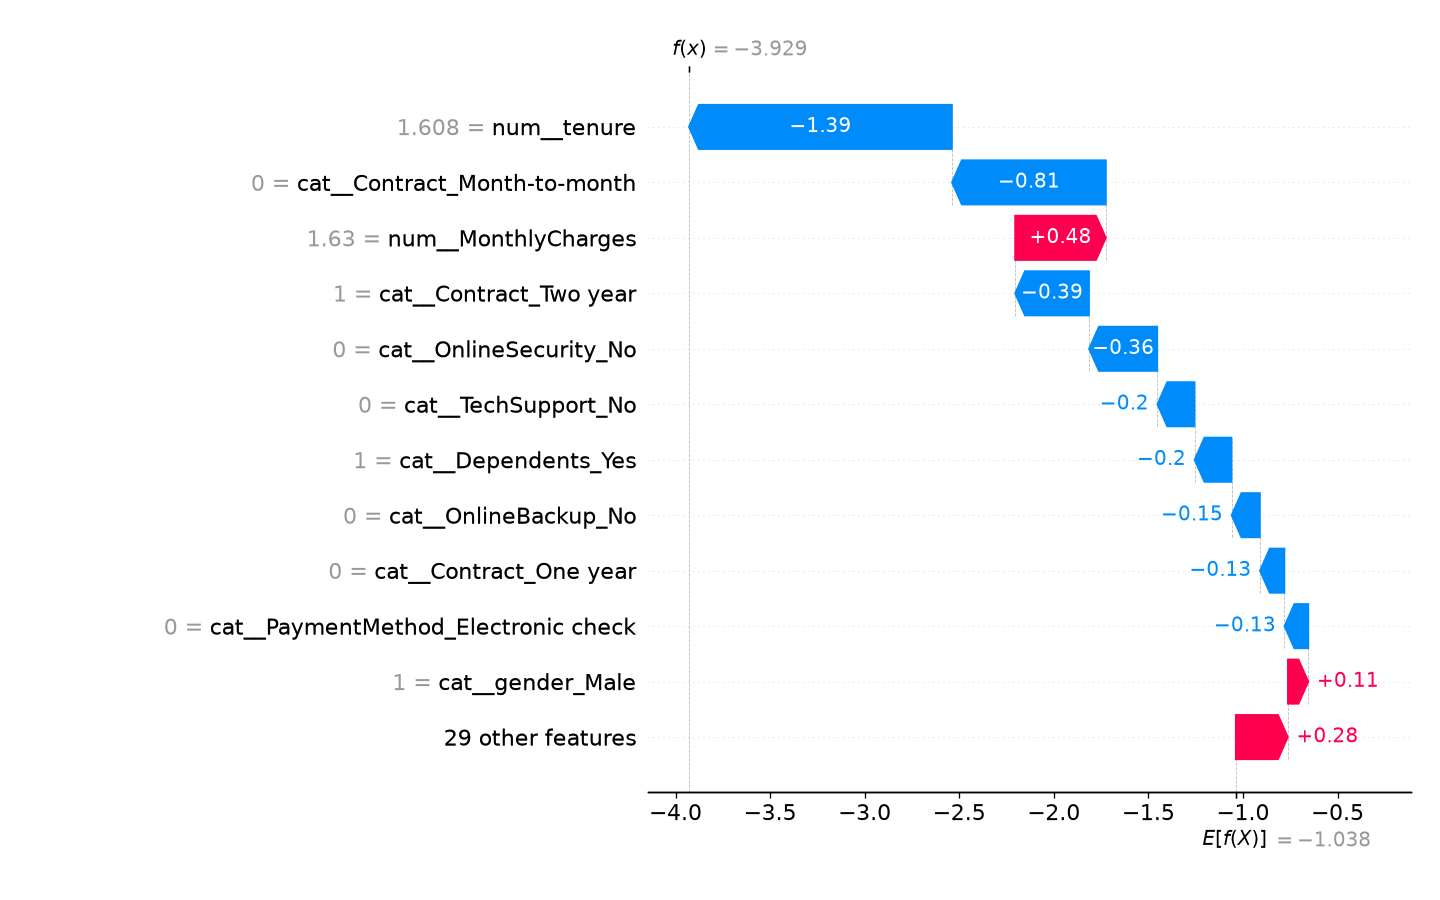

FP local explanation: d:\churnxai\reports\figures\shap_local_fp.png


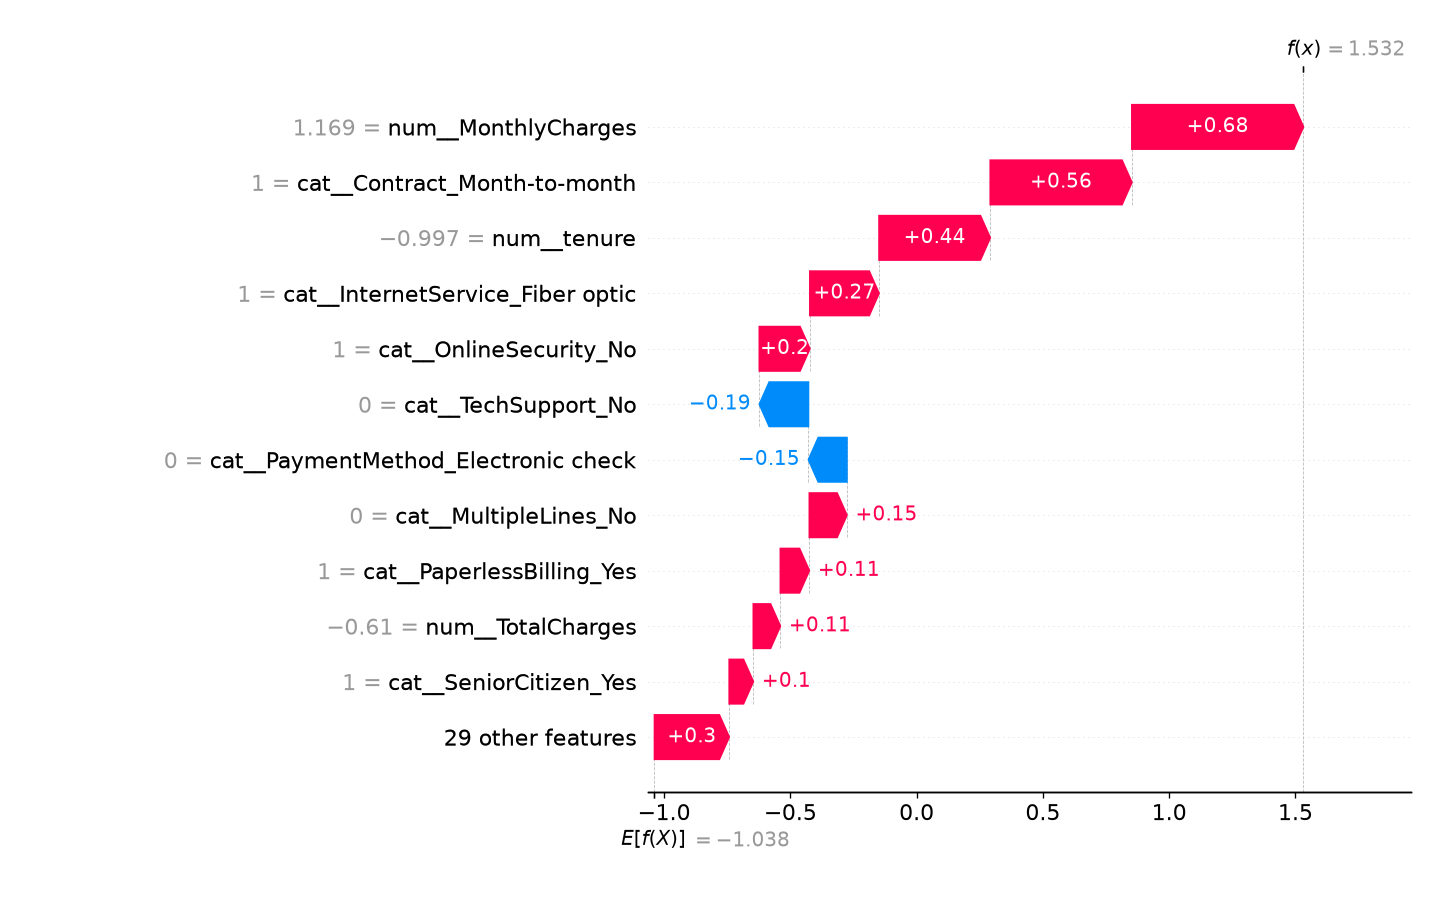

FN local explanation: d:\churnxai\reports\figures\shap_local_fn.png


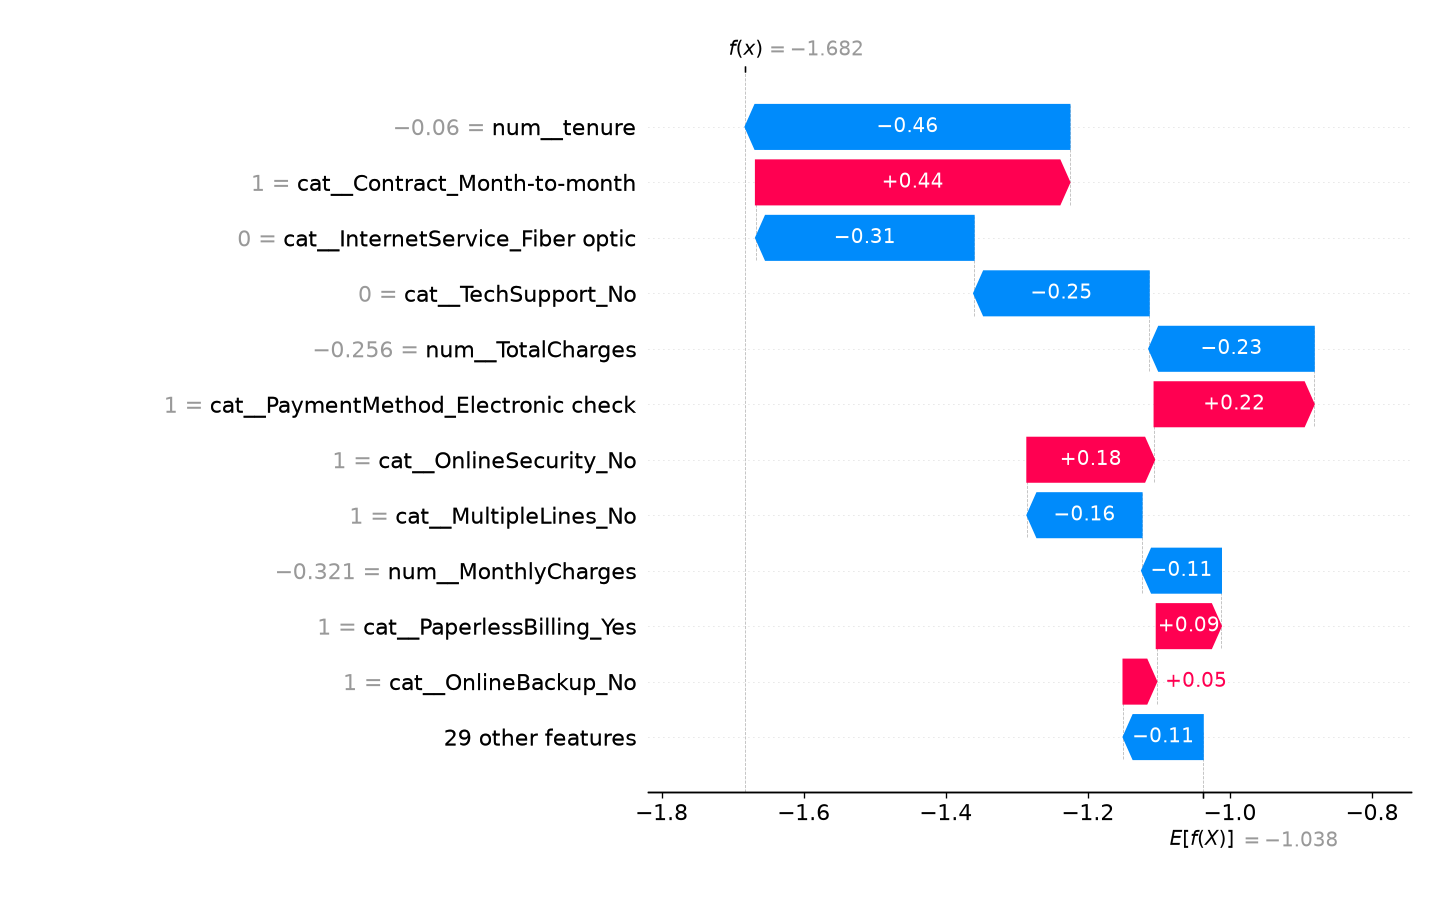

BORDERLINE local explanation: d:\churnxai\reports\figures\shap_local_borderline.png


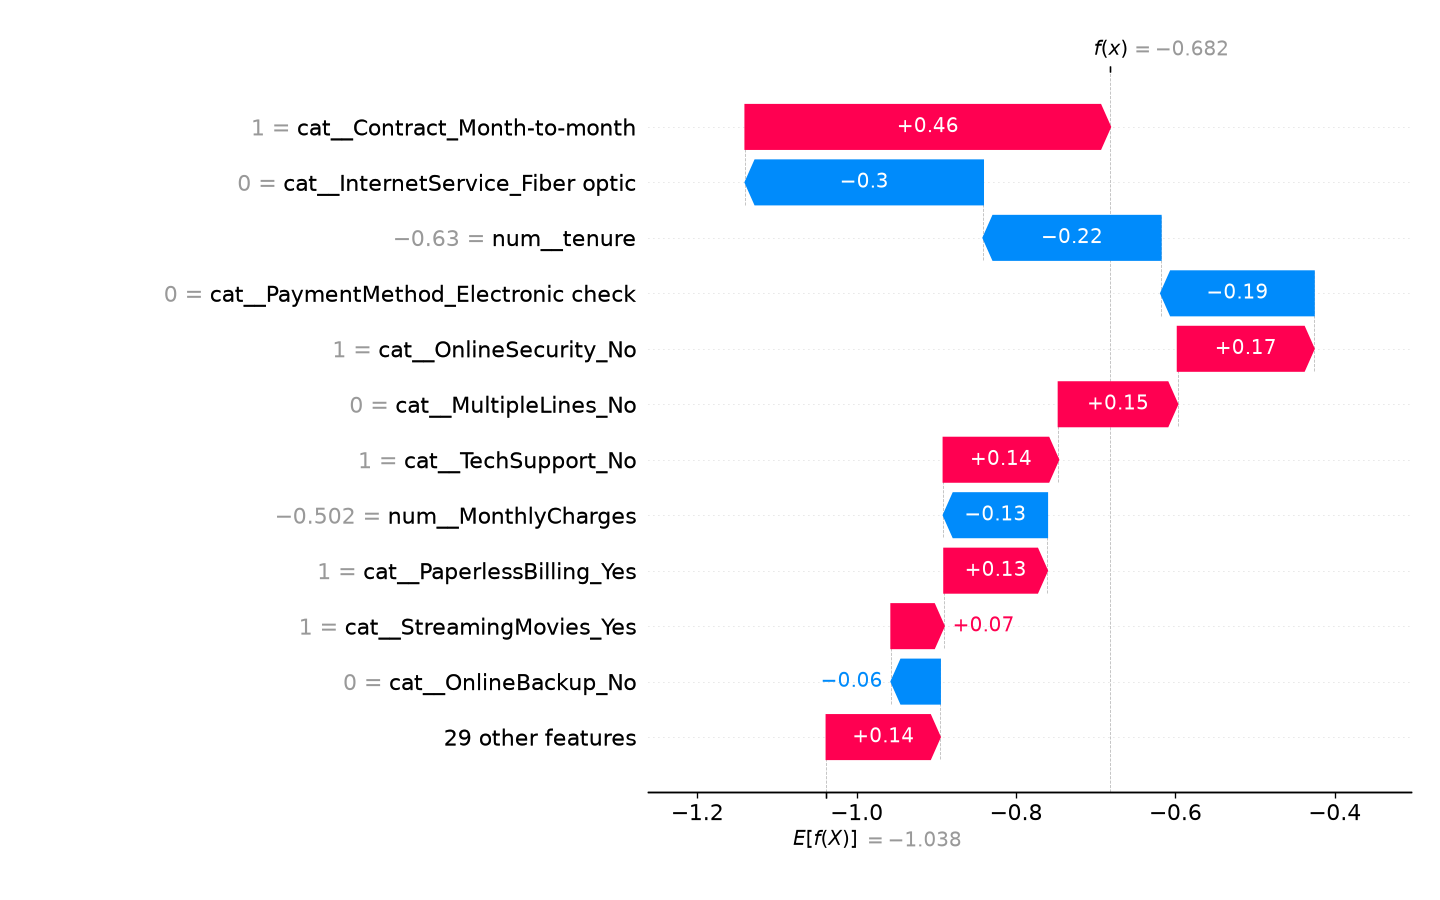

In [21]:
shap_report = metadata['shap']

print(f"Maximum SHAP additivity probability error: {shap_report['max_probability_additivity_error']:.2e}")

assert shap_report['max_probability_additivity_error'] < 1e-3

print(f"Global explanation: {shap_report['global_beeswarm']}")

display(Image(filename=shap_report['global_beeswarm']))

for case_name, image_path in shap_report['local_waterfalls'].items():

    if image_path is not None:

        print(f'{case_name.upper()} local explanation: {image_path}')

        display(Image(filename=image_path))